<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_python/da04_matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터프레임 준비

In [2]:
tips = sns.load_dataset(name='tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


# `matplotlib.pyplot` 모듈을 사용한 데이터 시각화

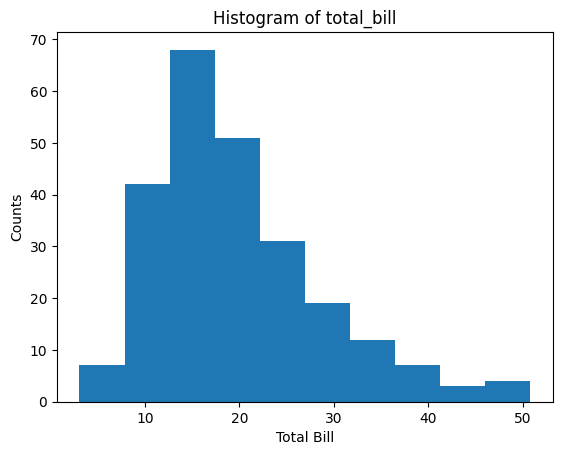

In [16]:
# 1. Figure 객체 생성.
fig = plt.figure()

# 2. Figure 객체에 Axes 설정(Subplot 설정).
# axis = fig.add_subplot(1, 1, 1)  # fig.add_subplot(nrows, ncols, index)
axis = fig.add_subplot(111)  # fig.add_subplot(pos): 행/열/인덱스 순서로 만들어진 3자리 정수

# 3. Axes에 그래프를 그림.
axis.hist(x=tips.total_bill)  # 히스토그램

# 4. 그래프의 옵션들 설정.
axis.set_title('Histogram of total_bill')
axis.set_xlabel('Total Bill')
axis.set_ylabel('Counts')

# 5. 그래프 보여주기.
plt.show()

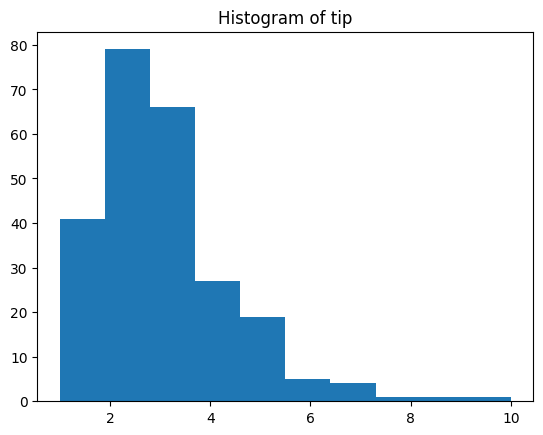

In [20]:
# 1. Figure, Axes 객체 생성.
fig, axis = plt.subplots()  # nrows=1, ncols=1 (default argument)

# 2. 그래프 그림.
axis.hist(x=tips.tip)

# 3. 옵션 설정.
axis.set_title('Histogram of tip')

# 4. 그래프 보여주기.
plt.show()

1개의 Figure에 1개의 Axis(Subplot)만 있는 경우에는, `matplotlib.pyplot` 모듈의 top-level 함수를 사용해서 간단히 그래프를 그릴 수 있음.

top-level 함수를 사용하면, Figure 또는 Axes 객체를 생성하는 코드를 명시적으로 작성할 필요가 없음.

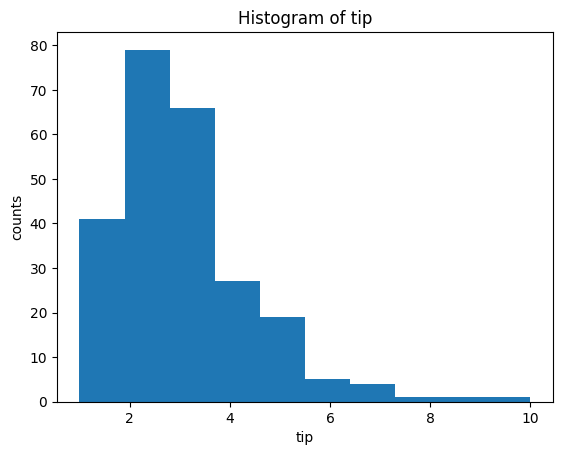

In [26]:
# Figure 생성 -> Axes 생성 -> 히스토그램 그리기.
plt.hist(x=tips.tip)

# 그래프 옵션
plt.title('Histogram of tip')
plt.xlabel('tip')
plt.ylabel('counts')

plt.show()

# Box Plot(상자 그림)

연속형 자료(숫자 타입 데이터)의 기술 통계량(최솟값, 1사분위값, 중앙값, 3사분위값, 최댓값)과 이상치(outliers)를 상자 모양으로 시각화한 그래프.

In [29]:
tips.total_bill.describe()

,total_bill
count,244.000000
mean,19.785943
std,8.902412
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,50.810000


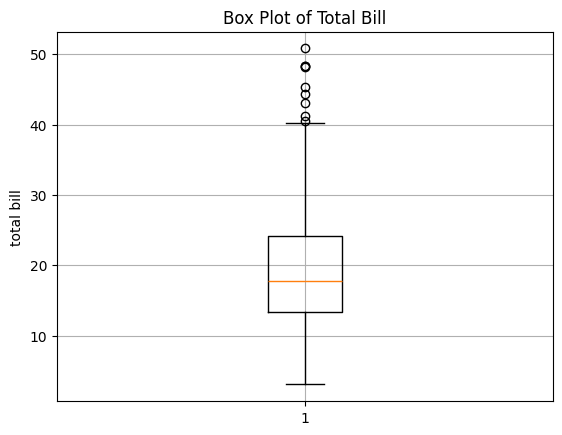

In [33]:
# 영수증 금액의 상자 그림
plt.boxplot(x=tips.total_bill)
plt.title('Box Plot of Total Bill')
plt.ylabel('total bill')
plt.grid()
plt.show()

IQR(inter-quartile range): 3사분위(75%)값 - 1사분위(25%)값

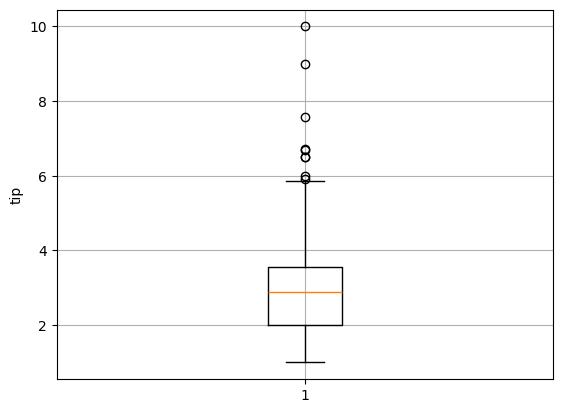

In [35]:
# 팁의 box plot
plt.boxplot(x=tips.tip)
plt.ylabel('tip')
plt.grid()
plt.show()

In [36]:
tips.tip.describe()

,tip
count,244.000000
mean,2.998279
std,1.383638
min,1.000000
25%,2.000000
50%,2.900000
75%,3.562500
max,10.000000


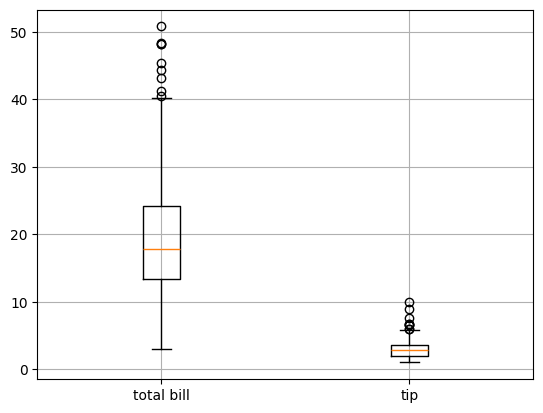

In [39]:
plt.boxplot(x=[tips.total_bill, tips.tip], tick_labels=['total bill', 'tip'])
plt.grid()
plt.show()

1개의 Figure 안에 2개의 Axes를 좌/우로 배치해서, 왼쪽에서 영수증 금액의 box plot을, 오른쪽에는 팁의 box plot을 시각화.

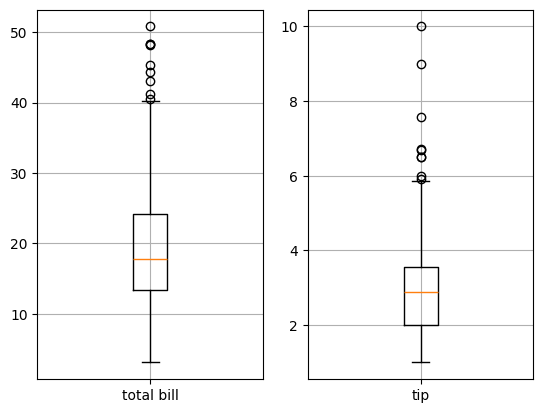

In [49]:
fig = plt.figure()  # Figure 객체 생성

ax1 = fig.add_subplot(1, 2, 1)  # 첫번째 Axes 객체 생성
ax2 = fig.add_subplot(122)  # 두번째 Axes 객체 생성

ax1.boxplot(x=tips.total_bill, tick_labels=['total bill'])  # 첫번째 축에 영수증 box plot
ax2.boxplot(x=tips.tip, tick_labels=['tip'])  # 두번째 축에 팁 box plot

ax1.grid()
ax2.grid()

plt.show()

[<Axes: > <Axes: >]
<class 'numpy.ndarray'>


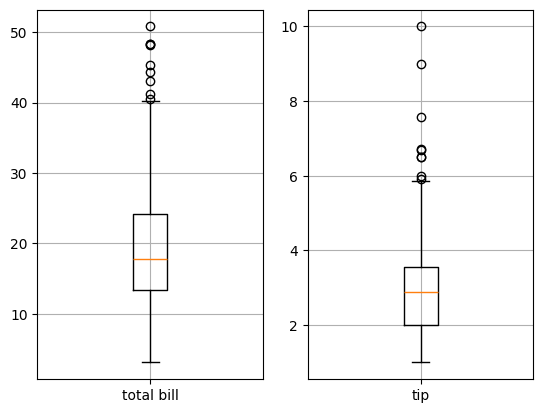

In [60]:
fig, axes = plt.subplots(ncols=2)

print(axes)  #> axes: Axes 클래스 객체들의 배열(numpy.ndarray)
print(type(axes))

axes[0].boxplot(x=tips.total_bill, tick_labels=['total bill'])
axes[0].grid()

axes[1].boxplot(x=tips.tip, tick_labels=['tip'])
axes[1].grid()

plt.show()

## 성별 팁의 box plot

*   남성의 팁의 기술 통계량 출력
*   여성의 팁의 기술 통계량 출력
*   1개의 Axes 안에 성별 팁의 box plot 2개를 시각화.

In [61]:
tips.sex.unique()

['Female', 'Male']
Categories (2, object): ['Male', 'Female']

In [62]:
# data_frame.category_column.cat.categories
# cat: CatergoricalAccessor(카테고리 타입 접근자)
tips.sex.cat.categories

Index(['Male', 'Female'], dtype='object')

In [63]:
for x in tips.sex.cat.categories:
    print(x)

Male
Female


In [65]:
tip_male = tips[tips.sex == 'Male'].tip
tip_male

,tip
1,1.66
2,3.50
3,3.31
5,4.71
6,2.00
...,...
236,1.00
237,1.17
239,5.92
241,2.00


In [66]:
tip_male.describe()  # 남성 팁의 기술 통계량

,tip
count,157.000000
mean,3.089618
std,1.489102
min,1.000000
25%,2.000000
50%,3.000000
75%,3.760000
max,10.000000


In [67]:
tip_female = tips[tips.sex == 'Female'].tip
tip_female.describe()  # 여성 팁 기술 통계량

,tip
count,87.000000
mean,2.833448
std,1.159495
min,1.000000
25%,2.000000
50%,2.750000
75%,3.500000
max,6.500000


In [72]:
tips.groupby(by='sex', observed=True).tip.describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Male,157.0,3.089618,1.489102,1.0,2.0,3.00,3.76,10.0
Female,87.0,2.833448,1.159495,1.0,2.0,2.75,3.50,6.5


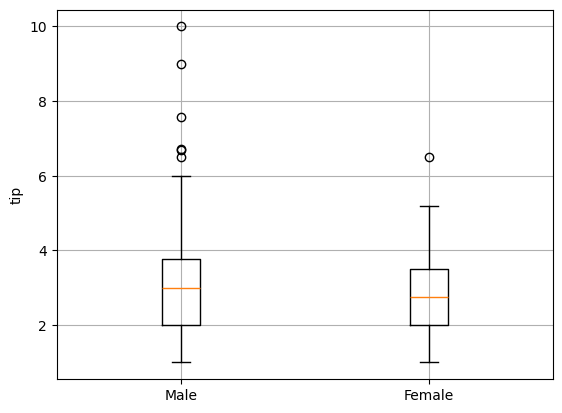

In [77]:
plt.boxplot(x=[tip_male, tip_female],
            tick_labels=tips.sex.cat.categories)
plt.ylabel('tip')
plt.grid()
plt.show()

## 시간별 팁의 box plot

In [89]:
tips.time.cat.categories

Index(['Lunch', 'Dinner'], dtype='object')

In [93]:
tip_lunch = tips[tips.time == 'Lunch'].tip

In [94]:
tip_lunch.describe()

,tip
count,68.000000
mean,2.728088
std,1.205345
min,1.250000
25%,2.000000
50%,2.250000
75%,3.287500
max,6.700000


In [99]:
tip_dinner = tips[tips.time == 'Dinner'].tip

In [100]:
tip_dinner.describe()

,tip
count,176.000000
mean,3.102670
std,1.436243
min,1.000000
25%,2.000000
50%,3.000000
75%,3.687500
max,10.000000


In [105]:
tips.groupby(by='time', observed=True).tip.describe()

,count,mean,std,min,25%,50%,75%,max
time,,,,,,,,
Lunch,68.0,2.728088,1.205345,1.25,2.0,2.25,3.2875,6.7
Dinner,176.0,3.102670,1.436243,1.00,2.0,3.00,3.6875,10.0


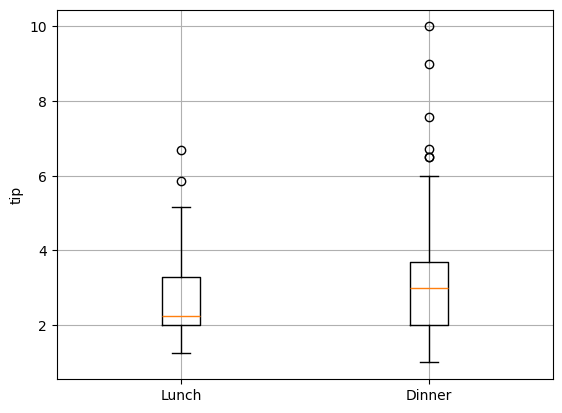

In [109]:
plt.boxplot(x=[tip_lunch, tip_dinner],
            tick_labels=tips.time.cat.categories)
plt.ylabel('tip')
plt.grid()
plt.show()

## 요일별 팁의 box plot

In [111]:
tips.groupby(by='day').tip.describe()

/tmp/ipykernel_2323/200232427.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips.groupby(by='day').tip.describe()


,count,mean,std,min,25%,50%,75%,max
day,,,,,,,,
Thur,62.0,2.771452,1.240223,1.25,2.0000,2.305,3.3625,6.70
Fri,19.0,2.734737,1.019577,1.00,1.9600,3.000,3.3650,4.73
Sat,87.0,2.993103,1.631014,1.00,2.0000,2.750,3.3700,10.00
Sun,76.0,3.255132,1.234880,1.01,2.0375,3.150,4.0000,6.50


In [112]:
days = tips.day.cat.categories
days

Index(['Thur', 'Fri', 'Sat', 'Sun'], dtype='object')

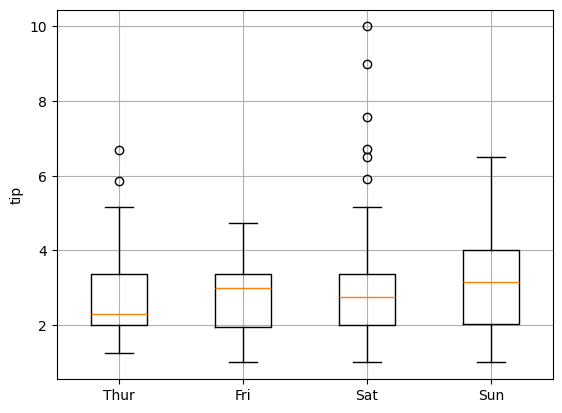

In [119]:
# Index 객체는 iterable --> for 반복문에서 사용.
# data = []  # 요일별 팁을 저장하기 위한 리스트.
# for d in days:
#     tip_by_day = tips[tips.day == d].tip
#     data.append(tip_by_day)
data = [ tips[tips.day == x].tip for x in days ]

plt.boxplot(x=data, tick_labels=days)
plt.ylabel('tip')
plt.grid()
plt.show()